# Audio Cleanup and Exploratory Analysis

This notebook loads the extracted audio file and performs basic analysis, such as waveform visualization, spectrogram, and statistics.

In [4]:
# Install required packages if needed
# !pip install numpy scipy matplotlib librosa

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import scipy.io.wavfile as wav
import os
import IPython.display as ipd

audio_path = "./data/fullySeated00.wav"

In [2]:
# Load audio file
y, sr = librosa.load(audio_path, sr=None, mono=True)
print(f"Audio loaded: {audio_path}")
print(f"Sample rate: {sr}, Duration: {len(y)/sr:.2f} seconds")

Audio loaded: ./data/fullySeated00.wav
Sample rate: 48000, Duration: 3.70 seconds


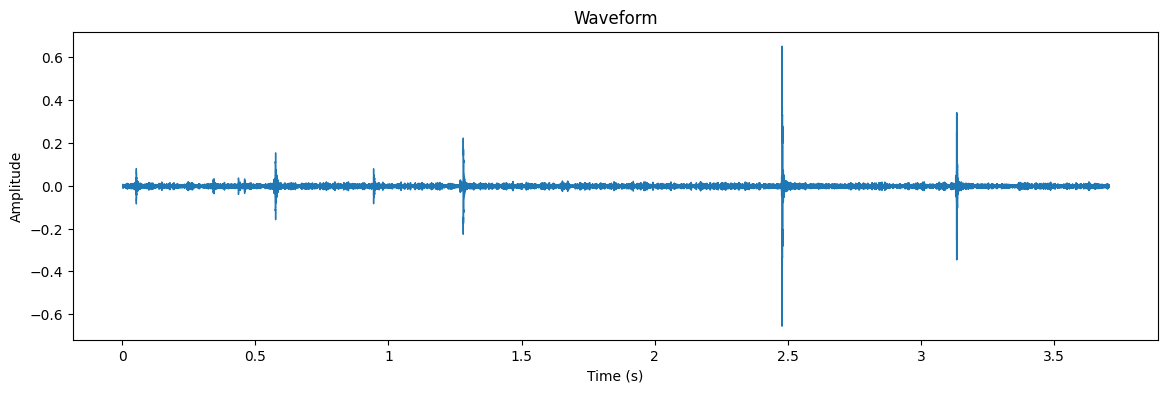

In [3]:
# Plot waveform
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

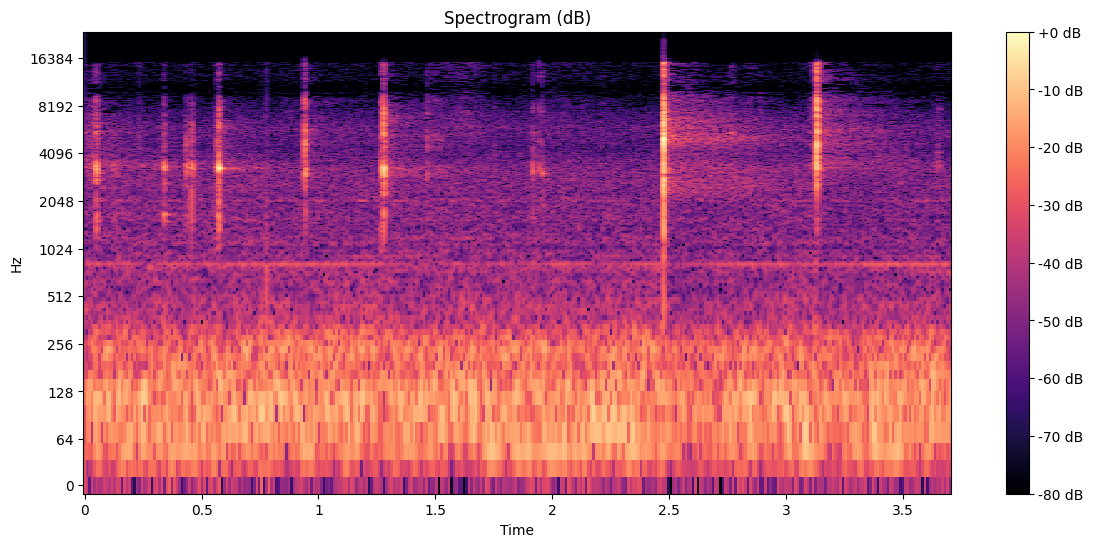

In [4]:
# Plot spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
plt.figure(figsize=(14, 6))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (dB)')
plt.show()

In [5]:
# Basic statistics
print(f"Mean amplitude: {np.mean(y):.4f}")
print(f"Std amplitude: {np.std(y):.4f}")
print(f"Max amplitude: {np.max(y):.4f}")
print(f"Min amplitude: {np.min(y):.4f}")

Mean amplitude: -0.0000
Std amplitude: 0.0100
Max amplitude: 0.6344
Min amplitude: -0.6542


In [6]:
def y_slice(length: float, start_sec: float = 0.0, bandpass=[4200, 4860]):
    """
    Slice the audio signal y into segments of specified length.
    
    :param y: Audio signal
    :param length: Length of each segment in seconds
    :param start_sec: Start time in seconds for slicing
    :return: List of audio segments
    """
    start_sample = int(start_sec * sr)
    end_sample = start_sample + int(length * sr)
    sample = y[start_sample:end_sample]

    if bandpass:
        from scipy.signal import butter, sosfilt
        sos = butter(N=6, Wn=bandpass, btype='bandpass', fs=sr, output='sos')
        sample = sosfilt(sos, sample)

    return sample

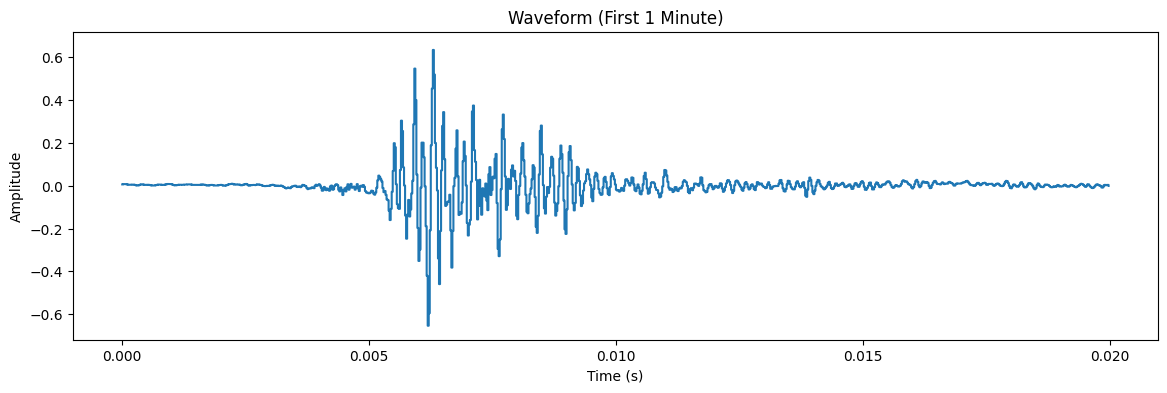

In [11]:
slice = y_slice(.02, 2.47, bandpass=None)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(slice, sr=sr)
plt.title("Waveform (First 1 Minute)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

ipd.Audio(slice, rate=sr)

Dominant frequencies (Hz):
5000.00 Hz (magnitude: 14.05)
5050.00 Hz (magnitude: 13.00)
5100.00 Hz (magnitude: 12.34)
4950.00 Hz (magnitude: 11.95)
4900.00 Hz (magnitude: 11.42)


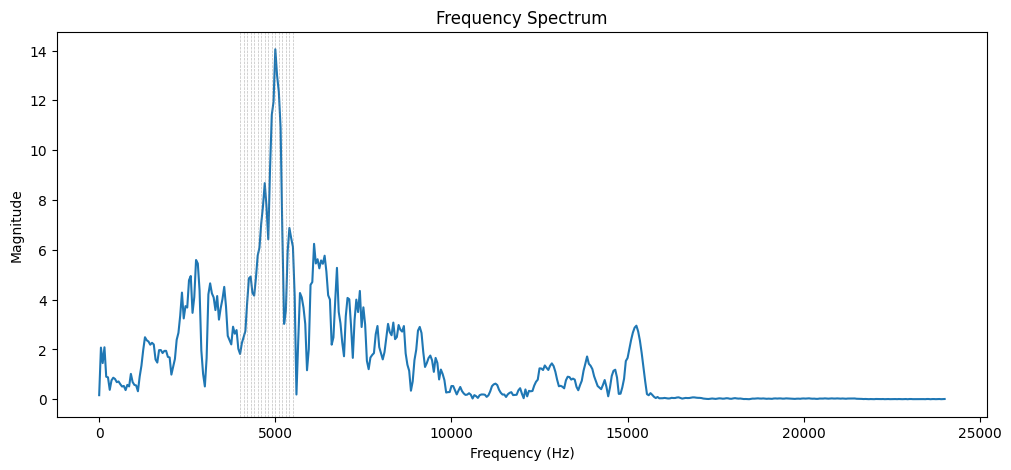

In [14]:
# Analyze dominant frequencies
#slice = y_slice(10, bandpass=None)
slice = y_slice(.02, 2.47, bandpass=None)

# Compute FFT
fft_spectrum = np.fft.rfft(slice)
freq = np.fft.rfftfreq(len(slice), d=1/sr)
magnitude = np.abs(fft_spectrum)

# Find dominant frequencies
top_n = 5
indices = np.argsort(magnitude)[-top_n:][::-1]
dominant_freqs = freq[indices]
dominant_mags = magnitude[indices]

print("Dominant frequencies (Hz):")
for f, m in zip(dominant_freqs, dominant_mags):
    print(f"{f:.2f} Hz (magnitude: {m:.2f})")

# Plot the spectrum
plt.figure(figsize=(12, 5))
plt.plot(freq, magnitude)
plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
#plt.xlim(4000, 5500)
#plt.xticks(np.arange(4000, 5501, 100))
for hz in np.arange(4000, 5501, 100):
    plt.axvline(hz, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()